# 01. Dataset Preparation and Descriptive Statistics 'Spend (Done).xlsx'

**How to use this notebook:**
- make a copy for each dataset: `01_data_prepare_deals.ipynb`, `01_data_prepare_calls.ipynb`, etc.
- fill in the config cell in each copy and go through all the steps
- write insights and decisions directly into the markdown cells

---
Tasks:   
`Data cleaning and preparation:`
1. Remove duplicates and irrelevant columns.
2. Handle missing values appropriately.
3. Convert data types for columns such as dates and numeric
values.

`Descriptive statistics:`
1. Calculate summary statistics (mean, median, mode,
range) for numeric fields.
2. Analyze categorical fields such as quality, stage, source, and
product.

---
## 1. Imports & Setup

In [ ]:
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

sys.path.append('../src')   # helpers.py lives in src/
import helpers as h

In [2]:
# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('deep')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paths (notebook lives in notebooks/, data lives in data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Create the backup folder if it doesn't exist yet
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Dataset Configuration for 'Spend (Done).xlsx'

Fill in `name` and `filename` **before running** the rest of the cells.

In [3]:
# ── DATASET CONFIG ──────────────────────────────────────────────────────────
# Fill in name and filename - the rest comes after preliminary analysis

dataset_config = {

    # Short dataset name (Latin letters, no spaces)
    # Used as the file name when saving the config and backups
    # Examples: 'deals', 'contacts', 'calls', 'spend'
    'name':       'spend',

    # Source file name in the data/raw/ folder
    'filename':   'Spend (Done).xlsx',
    'config_pkl': 'config_spend.pkl',
    'data_pkl':   'spend_cleaned.pkl'

}

print(f"Dataset: {dataset_config['name']}")
print(f"File:    {dataset_config['filename']}")

Dataset: spend
File:    Spend (Done).xlsx


---
## 3. Loading Data

In [4]:
# Load the dataset by filename from the config
filepath = RAW / dataset_config['filename']

# Determine format from the file extension
if filepath.suffix == '.xlsx':
    df = pd.read_excel(filepath, dtype={'Id': str, 'Contact Name': str})
else:
    raise ValueError(f"Unsupported file format: {filepath.suffix}")

print(f"Loaded: {dataset_config['filename']}")
df_size_prev = (f"Original dataset size:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_prev)

Loaded: Spend (Done).xlsx
Original dataset size:   20_779 rows × 8 columns


---
## 4. Preliminary Analysis


In [5]:
# First rows
df.head(10)

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN
3,2023-07-03,Google Ads,NaN,0,0.00,0,NaN,NaN
4,2023-07-03,CRM,NaN,0,0.00,0,NaN,NaN
5,2023-07-03,Facebook Ads,03.07.23women,187,3.30,6,women,b3
6,2023-07-03,Facebook Ads,03.07.23women,4,0.02,1,women,b1
7,2023-07-03,Bloggers,NaN,0,0.00,0,NaN,NaN
8,2023-07-03,Youtube Ads,NaN,0,0.00,0,NaN,NaN
9,2023-07-03,Facebook Ads,02.07.23wide_DE,61,0.58,0,wide,b4


### Dataset Description

|Column name  | Description |   
|------------------|----------|   
| **spend_date** | Spend date  |   
| **source** | Paid lead-acquisition channel |   
| **campaign** | Campaign the ad budget was spent on |   
| **impressions** |	Number of ad impressions on the given date |   
| **spend**	| Ad spend in euros |   
| **clicks** | Number of unique clicks on the ad link on the given date |   
| **ad_group** | Ad group name |   
| **ad** | Ad name |

### Cleaning Up Dataset Field Names

In [6]:
# Rename columns: strip whitespace and parentheses, convert to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Columns after renaming:")
print(df.columns.tolist())

Columns after renaming:
['date', 'source', 'campaign', 'impressions', 'spend', 'clicks', 'adgroup', 'ad']


In [7]:
# Rename specific columns
df.rename(columns={'date': 'spend_date', 'adgroup' : 'ad_group'}, inplace=True)
print("\nFirst rows of the DataFrame after renaming the field:")
df.head(3)


First rows of the DataFrame after renaming the field:


,spend_date,source,campaign,impressions,spend,clicks,ad_group,ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN


In [8]:
# Size and column dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20779 entries, 0 to 20778
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   spend_date   20779 non-null  datetime64[ns]
 1   source       20779 non-null  object        
 2   campaign     14785 non-null  object        
 3   impressions  20779 non-null  int64         
 4   spend        20779 non-null  float64       
 5   clicks       20779 non-null  int64         
 6   ad_group     13951 non-null  object        
 7   ad           13951 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 1.3+ MB


In [9]:
df.describe(include='all')

,spend_date,source,campaign,impressions,spend,clicks,ad_group,ad
count,20779,20779,14785,20779.00,20779.00,20779.00,13951,13951
unique,NaN,14,51,NaN,NaN,NaN,24,176
top,NaN,Facebook Ads,12.07.2023wide_DE,NaN,NaN,NaN,wide,bloggersvideo9com
freq,NaN,9732,2073,NaN,NaN,NaN,5451,714
mean,2024-01-14 22:32:40.864334080,NaN,NaN,2458.20,7.20,23.99,NaN,NaN
min,2023-07-03 00:00:00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
25%,2023-10-13 00:00:00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
50%,2024-01-27 00:00:00,NaN,NaN,63.00,0.58,1.00,NaN,NaN
75%,2024-04-16 00:00:00,NaN,NaN,709.00,5.75,12.00,NaN,NaN
max,2024-06-21 00:00:00,NaN,NaN,431445.00,774.00,2415.00,NaN,NaN


In [10]:
# Summary table for numeric columns 
h.descr_df(df)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,impressions,int64,20779,0,4003,0.00,0.00,2458.20,63.00,709.00,431445.00,431445.00,709.00
1,spend,float64,20779,0,2859,0.00,0.00,7.20,0.58,5.75,774.00,774.00,5.75
2,clicks,int64,20779,0,552,0.00,0.00,23.99,1.00,12.00,2415.00,2415.00,12.00


In [11]:
# Summary table for all columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,source,object,20779,0,14,Google Ads,Google Ads,Facebook Ads
1,campaign,object,14785,5994,51,gen_analyst_DE,performancemax_eng_DE,NaN
2,ad_group,object,13951,6828,24,NaN,NaN,NaN
3,ad,object,13951,6828,176,NaN,NaN,NaN


In [12]:
# Missing values - first look
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

,missing,%
ad_group,6828,32.90
ad,6828,32.90
campaign,5994,28.80


In [13]:
# Full duplicate rows - first look
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

Duplicate rows: 917


**Dataset description:** add here

Our 'Spend (Done)' dataset has 20_779 observations and 8 variables.  
Date - has the datetime64[ns] dtype.  
Numeric variables have the float64 or int64 dtype.   
Categorical variables Source, Campaign, AdGroup, Ad have the object dtype.

**Insights:** 

1) Column names had capital letters -> converted to snake_case.   
2) Some columns have missing values: Campaign, AdGroup, Ad.

---
## 5. Refining the Config: Column Types

Fill in the lists based on the preliminary analysis above.  
After filling them in, run the cell - the config will be saved.

In [14]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

['impressions', 'spend', 'clicks']


In [15]:
cat_cols = list(df.select_dtypes(include='object').columns)
print(cat_cols)

['source', 'campaign', 'ad_group', 'ad']


In [16]:
bool_cols = list(df.select_dtypes(include='bool').columns)
print(bool_cols)

[]


In [17]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

['spend_date']


In [18]:
# Fill in the lists based on Section 4's results ONCE, then run the code and comment it out
# If a column was already loaded from a saved config, it's fine to leave as-is

dataset_config['num_cols'] = [
    # Numeric: sla, initial_amount_paid, offer_total_amount, ...
    # '',
    *num_cols,
]

dataset_config['cat_cols'] = [
    # Categorical: stage, source, product, quality, ...
    # '',    
    *cat_cols,
]

dataset_config['bool_cols'] = [
    # Boolean (True/False or 0/1): e.g. scheduled_in_crm
    # '',
    *bool_cols
]

dataset_config['date_cols'] = [
    # Dates: created_time, closing_date, ...
    # '',
    *date_cols
]

dataset_config['drop_cols'] = [
    # Columns definitely not needed for analysis
    '',
]

# Remove empty placeholder strings from the lists
for key in ['num_cols', 'cat_cols', 'bool_cols', 'date_cols', 'drop_cols']:
    dataset_config[key] = [col for col in dataset_config[key] if col]

print("Config ready:")
print("=" * 50)
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config ready:
  name: spend
  filename: Spend (Done).xlsx
  config_pkl: config_spend.pkl
  data_pkl: spend_cleaned.pkl
  num_cols: ['impressions', 'spend', 'clicks']
  cat_cols: ['source', 'campaign', 'ad_group', 'ad']
  bool_cols: []
  date_cols: ['spend_date']
  drop_cols: []


### Saving the Config and Dataset to pkl

In [19]:
# Save the CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")

Config saved: data\processed\config_spend.pkl
Dataset saved: data\processed\spend_cleaned.pkl
Size: 20_779 × 8


---
## 6. Converting Data Types

### Datetime Columns

In [20]:
# Convert dates
for col in dataset_config['date_cols']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True)
        print(f"  {col} -> datetime {df[col].dtype}")

  spend_date -> datetime datetime64[ns]


### Numeric Columns

In [21]:
# Convert numeric columns
# errors='coerce' - non-numeric values become NaN
for col in dataset_config['num_cols']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"  {col} -> numeric {df[col].dtype}")

  impressions -> numeric int64
  spend -> numeric float64
  clicks -> numeric int64


### Boolean Columns

In [22]:
# Convert boolean columns
for col in dataset_config['bool_cols']:
    if col in df.columns:
        # Skip if the column is already bool
        if df[col].dtype != bool:
            df[col] = df[col].astype(bool)
        print(f"  {col} -> bool {df[col].dtype}")

There are no Boolean columns

### Columns Definitely Not Needed for Analysis

In [23]:
# Drop unneeded columns
if dataset_config['drop_cols']:
    df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
    print(f"Dropped columns: {dataset_config['drop_cols']}")

### Final Column Types

In [24]:
print("Config updated:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config updated:
  name: spend
  filename: Spend (Done).xlsx
  config_pkl: config_spend.pkl
  data_pkl: spend_cleaned.pkl
  num_cols: ['impressions', 'spend', 'clicks']
  cat_cols: ['source', 'campaign', 'ad_group', 'ad']
  bool_cols: []
  date_cols: ['spend_date']
  drop_cols: []


In [25]:
print(f"\nFinal column types:")
print(df.dtypes)


Final column types:
spend_date     datetime64[ns]
source                 object
campaign               object
impressions             int64
spend                 float64
clicks                  int64
ad_group               object
ad                     object
dtype: object


---
## 7. Duplicates

In [26]:
# Full duplicate rows
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Duplicate rows: 917


,spend_date,source,campaign,impressions,spend,clicks,ad_group,ad
753,2023-07-23,Bloggers,NaN,0,0.00,0,NaN,NaN
755,2023-07-23,Bloggers,NaN,0,0.00,0,NaN,NaN
768,2023-07-24,Bloggers,NaN,0,0.00,0,NaN,NaN
789,2023-07-24,Bloggers,NaN,0,0.00,0,NaN,NaN
841,2023-07-25,Bloggers,NaN,0,0.00,0,NaN,NaN
844,2023-07-25,Bloggers,NaN,0,0.00,0,NaN,NaN
895,2023-07-26,Bloggers,NaN,0,0.00,0,NaN,NaN
899,2023-07-26,Bloggers,NaN,0,0.00,0,NaN,NaN
950,2023-07-27,Bloggers,NaN,0,0.00,0,NaN,NaN
958,2023-07-27,Bloggers,NaN,0,0.00,0,NaN,NaN


**Decision on duplicates:** 

917 full duplicates found -> removed.

In [27]:
# Remove duplicates (uncomment if needed)
df = df.drop_duplicates().reset_index(drop=True)
print(f"After removing duplicates: {df.shape}")

After removing duplicates: (19862, 8)


---
## 8. Missing Values

In [28]:
# Final view of missing values after type conversion
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

,missing,%
ad_group,5911,29.80
ad,5911,29.80
campaign,5077,25.60


In [29]:
# First fix the ad hierarchy. The function lives in the helpers module because it is also used for the deals dataset
# Applies the hierarchy logic:
# hierarchy = [
#         ('ad', 'ad_group'),
#         ('ad_group', 'campaign'),
#         ('campaign', 'source')
#     ]
df = h.clean_marketing_hierarchy(df, "SPEND")

=== Processing hierarchy: SPEND ===
  [ad] by [ad_group]: recovered 0 values
  [ad_group] by [campaign]: recovered -77 values
  [campaign] by [source]: recovered 0 values
--- Done for SPEND. Remaining missing values: 0 ---



In [30]:
display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

,spend_date,source,campaign,impressions,spend,clicks,ad_group,ad


**Decision on missing values:**   
'ad', 'campaign', 'ad_group' - manually-filled fields, evidently the manager didn't enter the information.   
Transformed the ad hierarchy. The function lives in the helpers module because it is also used for the deals dataset.   
Applied hierarchy logic:   
hierarchy = [
         ('ad', 'ad_group'),
         ('ad_group', 'campaign'),
         ('campaign', 'source')
     ] --> based on which, filled values were propagated into the gaps.

In [31]:
# Handle missing values - fill in based on the decisions from the table above

# Example: fill numeric column with the median
# col = 'sla'
# df[col] = df[col].fillna(df[col].median())

# Example: fill categorical column with the mode
# col = 'payment_type'
# df[col] = df[col].fillna(df[col].mode()[0])

# Example: fill with a constant
# df['lost_reason'] = df['lost_reason'].fillna('not specified')

# Example: fill with the median within groups
# col = 'course_duration'
# df[col] = df[col].fillna(df.groupby(['product', 'education_type'])[col].transform('median'))
# If an entire group is empty, fall back to the global median
# df[col] = df[col].fillna(df[col].median())

# Check the result
print("Missing values after processing:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("No missing values")
else:
    print(remaining)

Missing values after processing:
No missing values


---
## 9. Univariate Analysis - Numeric Variables

For each numeric variable:
- histogram + boxplot via `h.hist_box`
- outlier bounds via `h.iqr_outliers`




────────────────────────────────────────────────────────────
  impressions
────────────────────────────────────────────────────────────


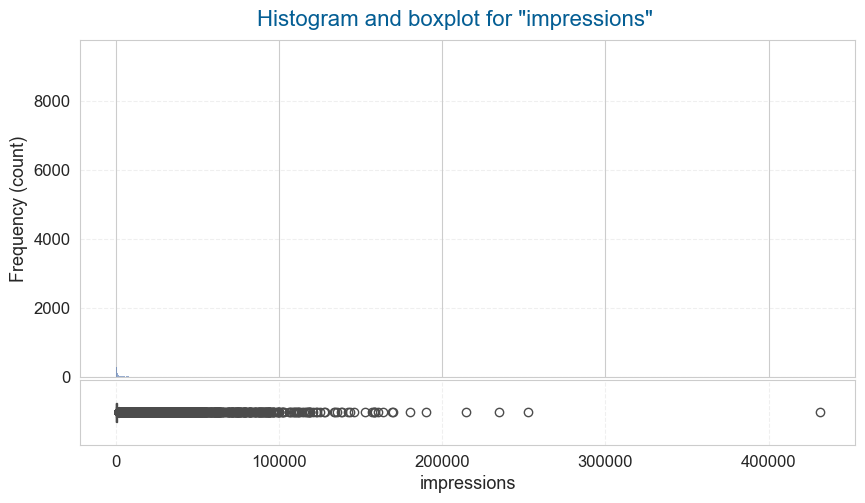

Descriptive statistics:


,0
Column name,impressions
Dtype,int64
Value count,19862
Missing (NaN),0
Unique values,4003
Min,0
Q1,1.00
Mean,2571.70
Q2 Median,82.00
Q3,760.75


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-1138.62,1900.38
Outlier count,0.00,2633.00
Outlier %,0.00,13.26



────────────────────────────────────────────────────────────
  spend
────────────────────────────────────────────────────────────


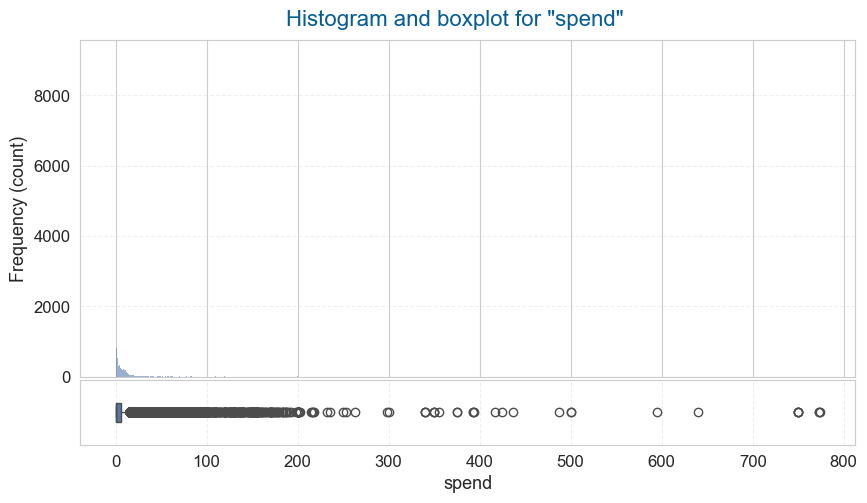

Descriptive statistics:


,0
Column name,spend
Dtype,float64
Value count,19862
Missing (NaN),0
Unique values,2859
Min,0.00
Q1,0.00
Mean,7.53
Q2 Median,0.74
Q3,6.16


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-9.24,15.40
Outlier count,0.00,1769.00
Outlier %,0.00,8.91



────────────────────────────────────────────────────────────
  clicks
────────────────────────────────────────────────────────────


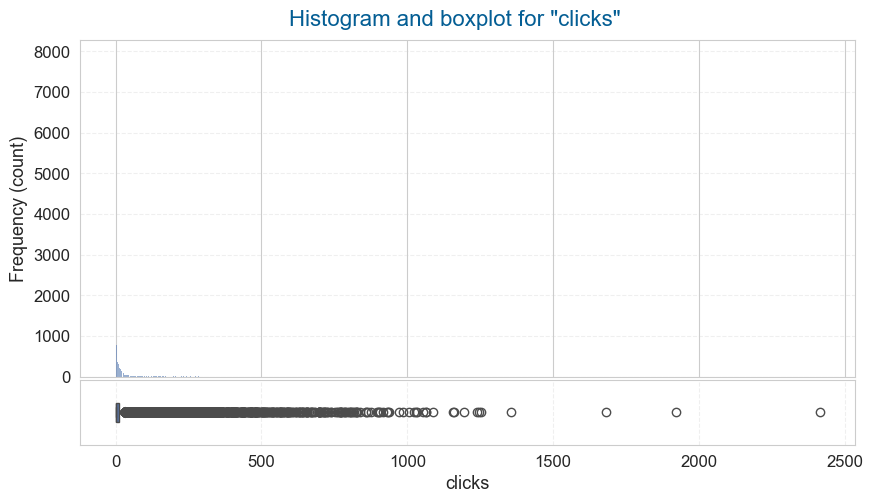

Descriptive statistics:


,0
Column name,clicks
Dtype,int64
Value count,19862
Missing (NaN),0
Unique values,552
Min,0
Q1,0.00
Mean,25.10
Q2 Median,2.00
Q3,13.00


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-19.50,32.50
Outlier count,0.00,2400.00
Outlier %,0.00,12.08


In [32]:
for col in dataset_config['num_cols']:
    if col not in df.columns:
        print(f"Column {col} not found in the dataset, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Histogram + boxplot
    h.hist_box(col, df, title=col)
    print('Descriptive statistics:')
    display(h.descr_df(df[[col]], show=False).T)

    # Table with quantiles and outlier bounds
    print('Whisker bounds and outliers:')
    h.iqr_outliers(col, df)

**Observations and outlier decisions:**

`spend`: €0-6 (median €0.74), 9% outliers   
`impressions`: 1-761 (median 82), 13% outliers   
`clicks`: 0-13 (median 2), 12% outliers   

Ads: low budgets (€7 avg), many zero impressions/clicks

In [33]:
# Handle outliers - fill in based on the decisions from the table above

# Example: remove right-side outliers
# col = 'sla'
# outliers = h.iqr_outliers(col, df, show=False)
# right_border = outliers.loc['Outlier bounds', 'Right']
# df = df[df[col] <= right_border].copy()
# print(f"After removing right-side outliers in {col}: {df.shape}")

# Example: remove left-side outliers
# col = 'initial_amount_paid'
# outliers = h.iqr_outliers(col, df, show=False)
# left_border = outliers.loc['Outlier bounds', 'Left']
# df = df[df[col] >= left_border].copy()

print(f"Dataset size after outlier handling: {df.shape}")

Dataset size after outlier handling: (19862, 8)


---
## 10. Univariate Analysis - Categorical Variables

For each categorical variable:
- frequency table with shares
- horizontal bar plot


────────────────────────────────────────────────────────────
  source  (14 unique values)
────────────────────────────────────────────────────────────


,source,count,%
0,Facebook Ads,9569,48.20
1,Tiktok Ads,2985,15.00
2,Youtube Ads,1784,9.00
3,Google Ads,1266,6.40
4,Telegram posts,836,4.20
5,Webinar,766,3.90
6,Bloggers,632,3.20
7,SMM,571,2.90
8,Organic,514,2.60
9,CRM,355,1.80


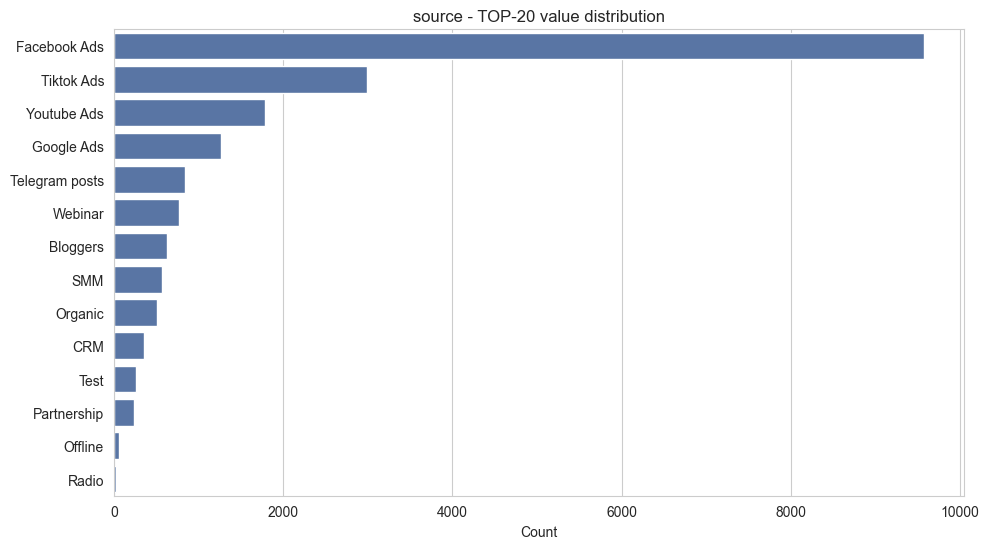


────────────────────────────────────────────────────────────
  campaign  (52 unique values)
────────────────────────────────────────────────────────────


,campaign,count,%
0,(no campaign),5077,25.60
1,12.07.2023wide_DE,2073,10.40
2,02.07.23wide_DE,1685,8.50
3,04.07.23recentlymoved_DE,1398,7.00
4,youtube_shorts_DE,1223,6.20
5,07.07.23LAL_DE,1181,5.90
6,03.07.23women,1171,5.90
7,12.09.23interests_Uxui_DE,1143,5.80
8,15.07.23b_DE,529,2.70
9,24.09.23retargeting_DE,504,2.50


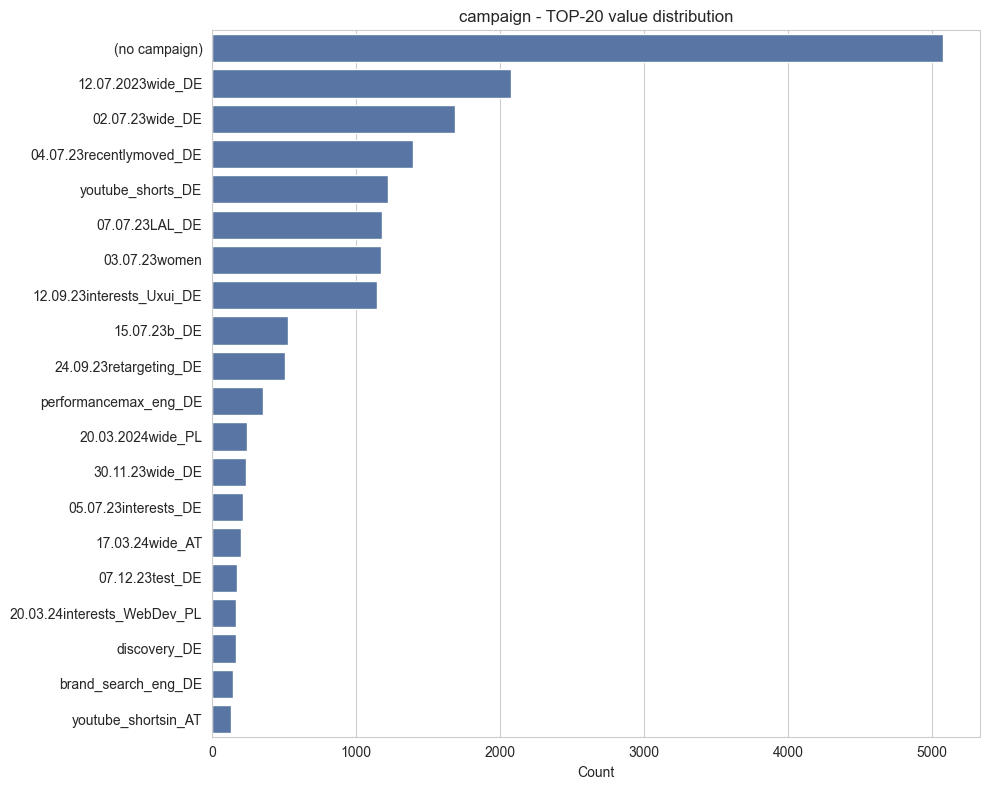


────────────────────────────────────────────────────────────
  ad_group  (24 unique values)
────────────────────────────────────────────────────────────


,ad_group,count,%
0,(no ad_group),5988,30.10
1,wide,5445,27.40
2,recentlymoved,1442,7.30
3,women,1274,6.40
4,LAL1,1220,6.10
5,Com_august,1073,5.40
6,interest_work_WebDev,733,3.70
7,interest_programming_WebDev,636,3.20
8,b,566,2.80
9,retargeting,504,2.50


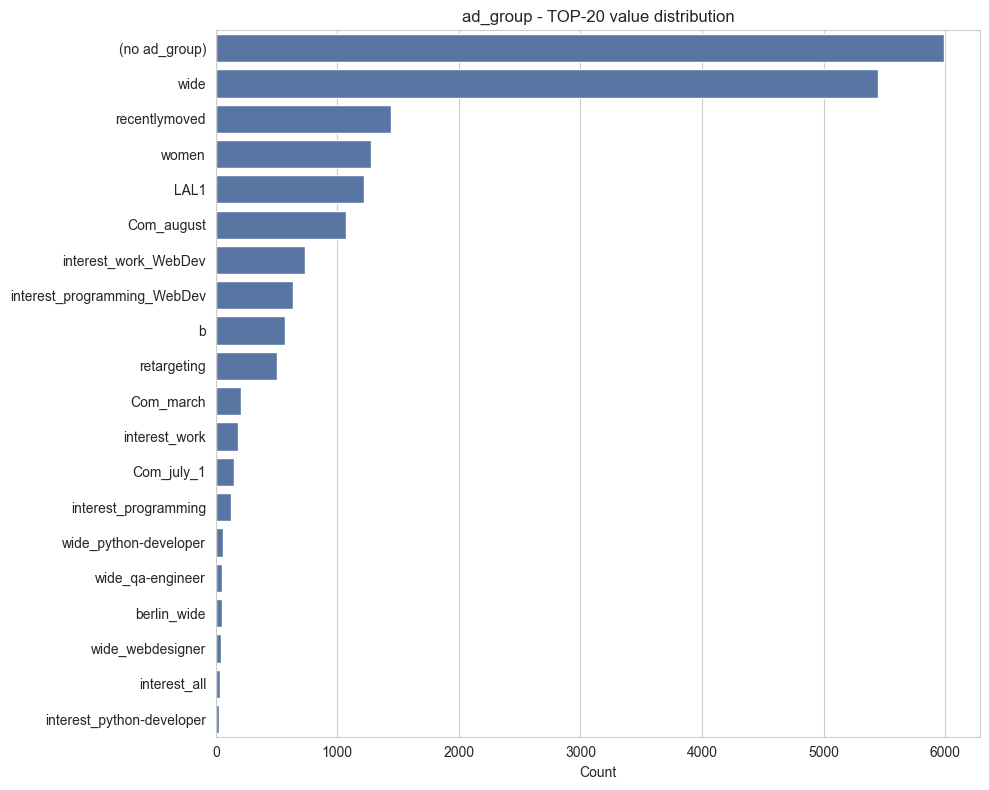


────────────────────────────────────────────────────────────
  ad  (177 unique values)
────────────────────────────────────────────────────────────


,ad,count,%
0,(no ad),5911,29.80
1,bloggersvideo9com,714,3.60
2,bloggersvideo5,711,3.60
3,bloggersvideo3com,565,2.80
4,bloggersvideo8com,536,2.70
...,...,...,...
172,ad3,2,0.00
173,b8offlinewebinar,2,0.00
174,b10offlinewebinar,2,0.00
175,b9offlinewebinar,2,0.00


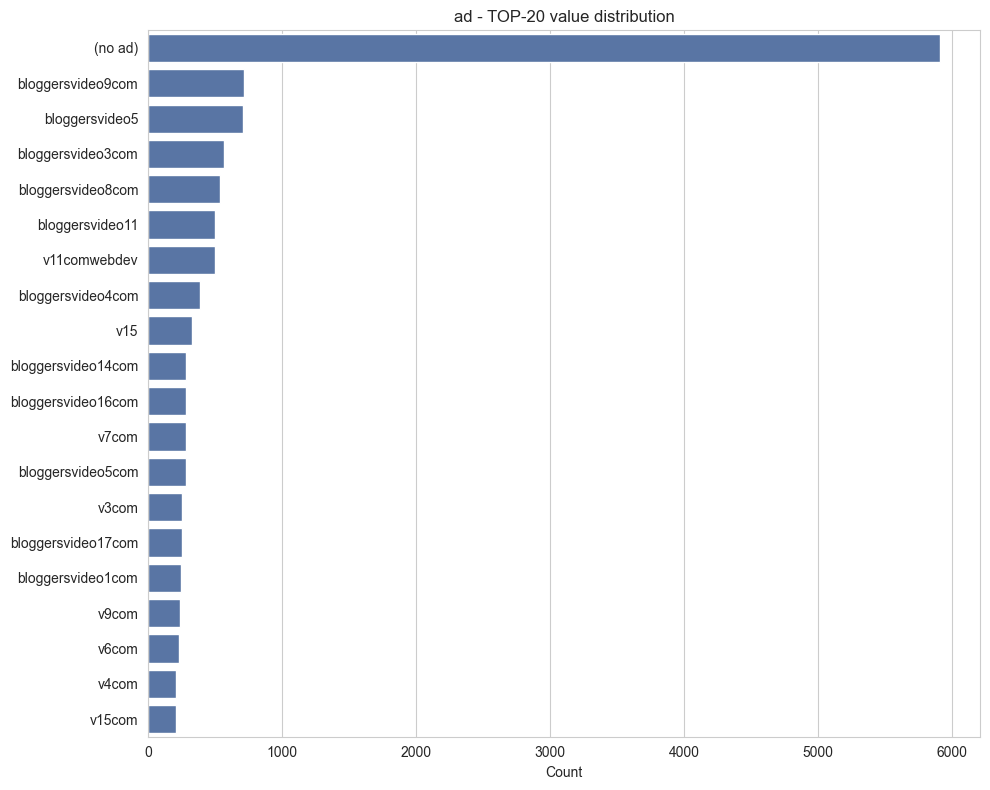

In [34]:
plt_to_save_png = ['source', 'campaign', 'adgroup', 'ad']  # Specify which variable's chart to save

for col in dataset_config['cat_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}  ({df[col].nunique()} unique values)")
    print(f"{'─'*60}")

    # Frequency table
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq)

    # Bar plot (top 20 values if more)
    top_vals = freq.head(20)

    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', orient='h')
    plt.title(f"{col} - TOP-20 value distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    if col in plt_to_save_png:
        plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_barplot.png",
                    dpi=150, bbox_inches='tight')
    plt.show()

**Observations and decisions:**    

`source:` FB Ads 48% >> Tiktok 15% >> YT/Google 15%, channels are balanced   
`campaign`: (no campaign) 26%, wide_DE 30%, 52 campaigns   
`ad_group`: (no ad_group) 30% + wide 27%, 24 groups   
`ad`: (no ad) 30%, bloggersvideo 15%, 177 ads*   

Ads: FB dominates, wide campaigns, 30% without detail

---
## 11. Univariate Analysis - Date Columns

For each date column:
- range and basic statistics
- monthly distribution (time series)


────────────────────────────────────────────────────────────
  spend_date
────────────────────────────────────────────────────────────
  Min:  2023-07-03 00:00:00
  Max: 2024-06-21 00:00:00
  Missing: 0


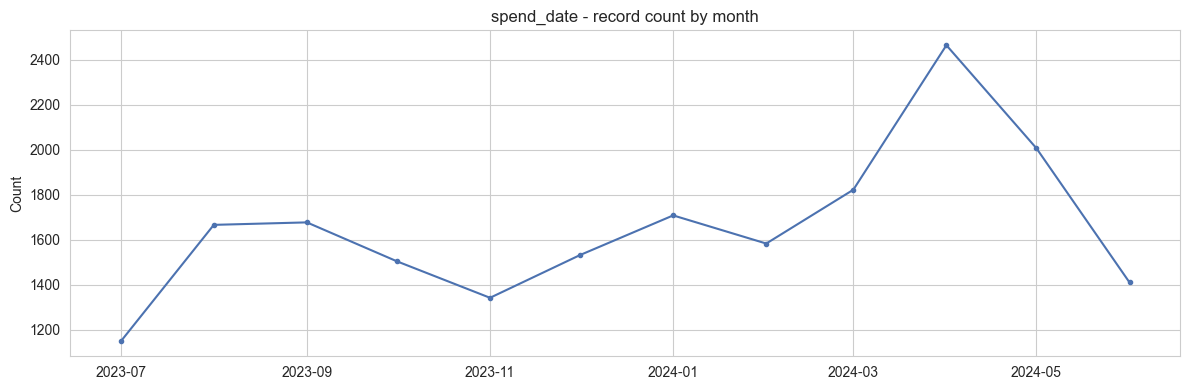

In [35]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Basic statistics
    print(f"  Min:  {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Missing: {df[col].isnull().sum()}")

    # Monthly time series
    monthly = df.set_index(col).resample('MS').size()

    plt.figure(figsize=(12, 4))
    plt.plot(monthly.index, monthly.values, marker='o', markersize=3, linewidth=1.5)
    plt.title(f"{col} - record count by month")
    plt.ylabel("Count")
    plt.xlabel("")
    plt.tight_layout()
    # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png",
    #             dpi=150, bbox_inches='tight')
    plt.show()

**Date observations:**

`spend_date`  Min:  2023-07-03 - Max: 2024-06-21 
the highest record count occurs in 04-2024 - over 2400 records

---
## 12. Univariate Analysis - Boolean Variables

For boolean variables, look at the True / False ratio.

In [36]:
# for col in dataset_config['bool_cols']:
#     if col not in df.columns:
#         print(f"Column {col} not found, skipping")
#         continue

#     print(f"\n{'─'*60}")
#     print(f"  {col}")
#     print(f"{'─'*60}")

#     # Frequency table
#     freq = df[col].value_counts().reset_index()
#     freq.columns = [col, 'count']
#     freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
#     display(freq)

#     # Pie chart
#     plt.figure(figsize=(5, 5))
#     plt.pie(freq['count'], labels=freq[col].astype(str),
#             autopct='%1.1f%%', startangle=90)
#     plt.title(f"{col}")
#     plt.tight_layout()
#     # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_pie.png",
#     #             dpi=150, bbox_inches='tight')
#     plt.show()

There are no Boolean columns

---
## 13. Saving

Save the cleaned dataset to `data/processed/` as parquet.  
If a file with that name already exists, it's moved to `data/processed/backup/` with a timestamp.  
The config is updated in `data/processed/`.

In [37]:
# Save the updated dataset to xlsx
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# If the file already exists - back it up before overwriting
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Previous file -> backed up as: {backup_path.name}")

# Save the cleaned dataset
df.to_excel(dataset_path, index=False)
print(f"Dataset saved:  {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size:            {df.shape[0]:_} rows × {df.shape[1]} columns")

Previous file -> backed up as: spend_cleaned_20261005_0854.xlsx
Dataset saved:  data\processed\spend_cleaned.xlsx
Size:            19_862 rows × 8 columns


In [38]:
# Save the updated CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the updated DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")

Config saved: data\processed\config_spend.pkl
Dataset saved: data\processed\spend_cleaned.pkl
Size: 19_862 × 8


In [39]:
# Check that everything was saved
print("Contents of the processed/ folder:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Contents of the backup/ folder:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Contents of the processed/ folder:
  calls_cleaned.pkl  (6768.8 KB)
  calls_cleaned.xlsx  (4887.0 KB)
  config_calls.pkl  (0.3 KB)
  config_contacts.pkl  (0.3 KB)
  config_deals.pkl  (0.5 KB)
  config_spend.pkl  (0.3 KB)
  contacts_cleaned.pkl  (871.5 KB)
  contacts_cleaned.xlsx  (568.0 KB)
  deals_cleaned.pkl  (3431.9 KB)
  deals_cleaned.xlsx  (2579.8 KB)
  deals_real_student.xlsx  (124.0 KB)
  spend_cleaned.pkl  (1157.2 KB)
  spend_cleaned.xlsx  (736.0 KB)

Contents of the backup/ folder:
  calls_cleaned_20261005_0841.xlsx  (4887.0 KB)
  contacts_cleaned_20261005_0843.xlsx  (568.0 KB)
  spend_cleaned_20261005_0854.xlsx  (736.0 KB)


---
## 14. Final Descriptive Statistics

In [40]:
# Can be loaded from PROCESSED to confirm everything was saved correctly 
# dataset_path

In [41]:
# Load the dataset by filename

dataset_path = PROCESSED / dataset_config['data_pkl']

# Load the cleaned dataset
df = pd.read_pickle(dataset_path)

# Print info about the load result
print(f"Loaded dataset: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Type: {type(df)} ")
print("=" * 80)
# Original dataset size:
print(df_size_prev)
df_size_old = (f"Dataset size after processing:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_old)

print("=" * 80)
df.info()

Loaded dataset: data\processed\spend_cleaned.pkl
Type: <class 'pandas.core.frame.DataFrame'> 
Original dataset size:   20_779 rows × 8 columns
Dataset size after processing:   19_862 rows × 8 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19862 entries, 0 to 19861
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   spend_date   19862 non-null  datetime64[ns]
 1   source       19862 non-null  object        
 2   campaign     19862 non-null  object        
 3   impressions  19862 non-null  int64         
 4   spend        19862 non-null  float64       
 5   clicks       19862 non-null  int64         
 6   ad_group     19862 non-null  object        
 7   ad           19862 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 1.2+ MB


In [42]:
df.describe(include='all')

,spend_date,source,campaign,impressions,spend,clicks,ad_group,ad
count,19862,19862,19862,19862.00,19862.00,19862.00,19862,19862
unique,NaN,14,52,NaN,NaN,NaN,24,177
top,NaN,Facebook Ads,(no campaign),NaN,NaN,NaN,(no ad_group),(no ad)
freq,NaN,9569,5077,NaN,NaN,NaN,5988,5911
mean,2024-01-10 18:21:55.879568896,NaN,NaN,2571.70,7.53,25.10,NaN,NaN
min,2023-07-03 00:00:00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
25%,2023-10-09 00:00:00,NaN,NaN,1.00,0.00,0.00,NaN,NaN
50%,2024-01-20 00:00:00,NaN,NaN,82.00,0.74,2.00,NaN,NaN
75%,2024-04-12 00:00:00,NaN,NaN,760.75,6.16,13.00,NaN,NaN
max,2024-06-21 00:00:00,NaN,NaN,431445.00,774.00,2415.00,NaN,NaN


In [43]:
# Summary table for numeric columns 
h.descr_df(df)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,impressions,int64,19862,0,4003,0.00,1.00,2571.70,82.00,760.75,431445.00,431445.00,759.75
1,spend,float64,19862,0,2859,0.00,0.00,7.53,0.74,6.16,774.00,774.00,6.16
2,clicks,int64,19862,0,552,0.00,0.00,25.10,2.00,13.00,2415.00,2415.00,13.00


`impressions`
Mean: 2,572 impressions per day   
Median: 761 - much lower than the mean   
Max: 431,445 (a very high outlier) 13% outliers   
Conclusion: The distribution is heavily right-skewed. Most days have low reach, but there are occasional days with very strong reach (likely major launches or successful creatives).   
Enormous spread - range = 431_445   

`spend`   
Average daily spend: 7.53   
Median: 6.16   
Max: 774
9% outliers   
range = 774    
Conclusion: On average, spend is relatively modest, but there are days with very high spend (100+ times the median). This is a typical pattern for manually-managed bid advertising. 

`clicks`   
Mean: 25.1 clicks per day   
Median: 13 clicks      
Max: 2,415    
12% outliers    
range = 2_415    
Conclusion: Same pattern - strong right skew. Most days produce few clicks, but there are days of very high performance.   

Ads: low budgets, many "0"s, CTR ~1%   
**Overall picture**:   

The data has a distribution with a heavy right tail (many outliers).   
Medians are significantly below the means across all metrics - this shows that most days have modest results, and the headline figures are pulled up by rare "lucky" days.    
CTR (clicks / impressions) is very low on average (~1%), which is typical for cold traffic in the online-education niche.

In [44]:
# Summary table for object columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,source,object,19862,0,14,Google Ads,Google Ads,Facebook Ads
1,campaign,object,19862,0,52,gen_analyst_DE,performancemax_eng_DE,(no campaign)
2,ad_group,object,19862,0,24,(no ad_group),(no ad_group),(no ad_group)
3,ad,object,19862,0,177,(no ad),(no ad),(no ad)


`source`: 14 channels (Google/FB Ads)
`campaign`: 52 (gen_analyst_DE), 0 missing
`ad_group/ad`: 24/177, (no ad_group/ad) 30%

Ads are structured, 30% without detail

In [45]:
# Summary table for bool columns 
h.descr_df(df, include=['bool'], show_stats=True, show_sample_rows=True)

No columns of type ['bool'] found in the dataset


In [46]:
# Summary table for datetime columns 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,spend_date,datetime64[ns],19862,0,355,2023-07-03,2023-07-03,2023-07-03


In [47]:
# Date range
cols = ['spend_date']
for col in cols:
    print(f"{'─'*80}")    
    print(f" {col}:  Min:  {df[col].min()} - Max: {df[col].max()}")
    print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
 spend_date:  Min:  2023-07-03 00:00:00 - Max: 2024-06-21 00:00:00
────────────────────────────────────────────────────────────────────────────────


---
**Dataset summary:**  
---
### Dataset Description

|Column name  | Description | dtypes |     
|------------------|----------|--------|     
| **spend_date** | Spend date  | datetime64[ns] |     
| **source** | Paid lead-acquisition channel | object |     
| **campaign** | Campaign the ad budget was spent on |  object |    
| **impressions** |	Number of ad impressions on the given date | int64 |     
| **spend**	| Ad spend in euros | float64 |     
| **clicks** | Number of unique clicks on the ad link on the given date | int64 |     
| **ad_group** | Ad group name | object |     
| **ad** | Ad name | object |   

**Column renaming:**   
Renamed columns (to snake_case, no parentheses or spaces).  
date -> spend_date - consistent style,   
adgroup -> ad_group - consistent style   

`Original dataset size:`   20_779 rows × 8 columns    
`Size after all iterations:`        19_862 rows × 8 columns     
`Missing:` 0 

**Decision on missing values:**   
ad, campaign, ad_group - manually-filled fields, evidently the manager didn't enter the information -> filled in via hierarchical propagation across the whole dataset.     
 
**Duplicates:**  
917 full duplicate rows removed.  

spend_date   
──────────────────────────────────────────   
  Min:  2023-07-03 00:00:00   
  Max: 2024-06-21 00:00:00   
  Missing: 0